Shape: (3650, 53)


,column,score,forward_r2,backward_r2,coef_similarity
0,col_50,1.431241,0.953405,0.977230,0.931847
1,col_11,1.428447,0.953794,0.981904,0.921195
2,col_42,1.423673,0.954152,0.974123,0.919071
3,col_26,1.354888,0.929997,0.928177,0.851602
4,col_28,1.336099,0.851968,0.894572,0.925658
5,col_05,1.284928,0.845508,0.880893,0.843456
6,col_20,1.279503,0.918978,0.921909,0.718118
7,col_30,1.231093,0.924800,0.955456,0.581931
8,col_19,1.223244,0.780555,0.828546,0.837386
9,col_48,1.201624,0.916491,0.947972,0.538784


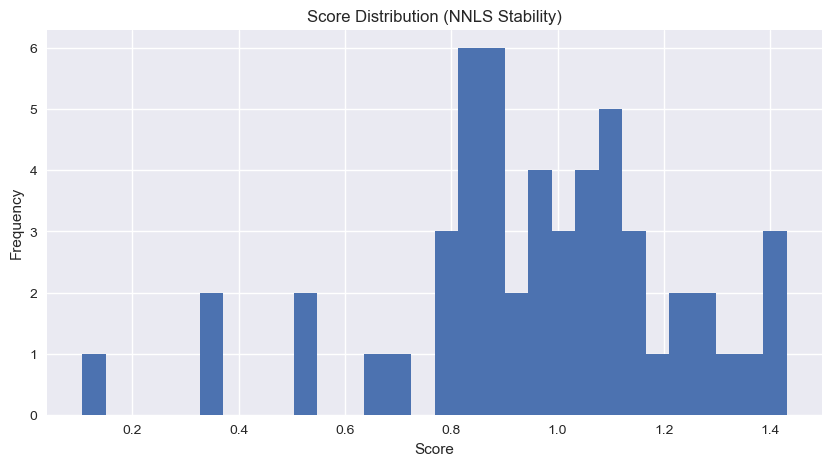

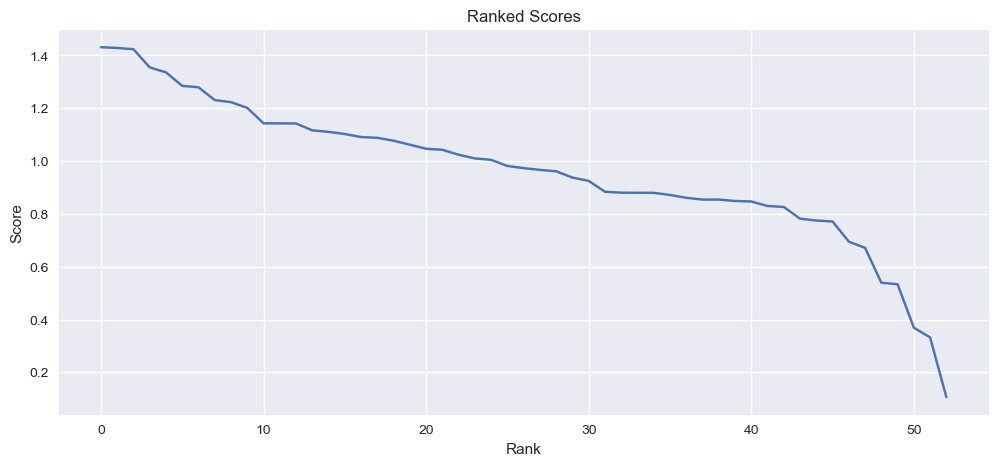

Top candidates: ['col_50', 'col_11', 'col_42', 'col_26', 'col_28', 'col_05', 'col_20', 'col_30', 'col_19', 'col_48']


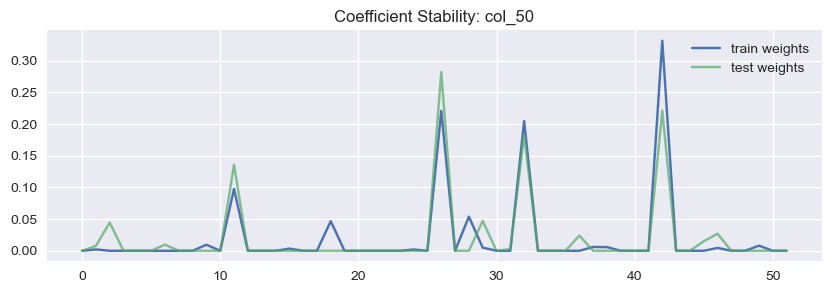

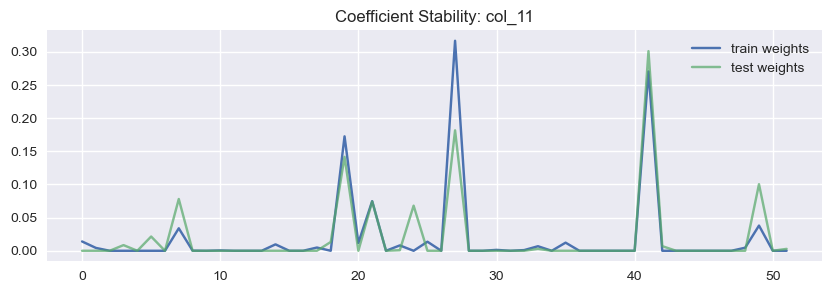

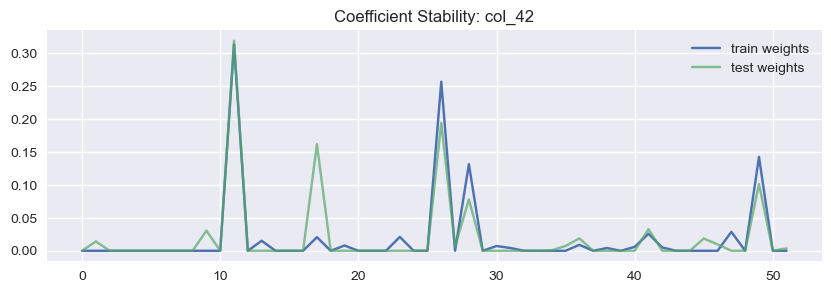

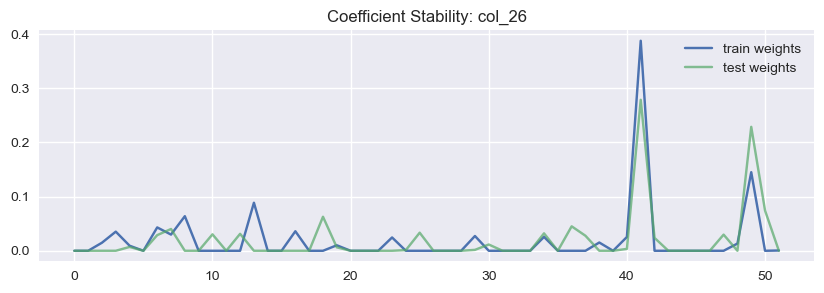

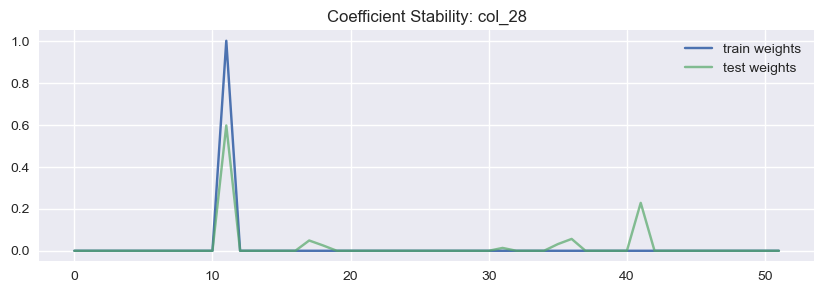

Final predicted index columns:
['col_50', 'col_11', 'col_42']


In [1]:
# =========================================
# 📦 0. IMPORTS
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from scipy.spatial.distance import cosine

plt.style.use("seaborn-v0_8")

# =========================================
# 📂 1. LOAD DATA
# =========================================
df = pd.read_csv("limestone_data_challenge_2026.data.csv")

cols = [c for c in df.columns if c != "time"]

# simple fill (same as Codex)
X = df[cols].interpolate(limit_direction="both").values

print("Shape:", X.shape)

# =========================================
# 🧠 2. CORE IDEA
# =========================================
"""
We test:
Can a column be reconstructed as a stable NONNEGATIVE combination of others?

If YES → likely index
If NO  → likely farmer

We measure:
- forward R²
- backward R²
- coefficient similarity
"""

def adjusted_r2(y, pred, p):
    ss_res = np.sum((y - pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    if ss_tot == 0:
        return 0
    r2 = 1 - ss_res / ss_tot
    n = len(y)
    if n <= p + 1:
        return r2
    return 1 - (1 - r2)*(n-1)/(n-p-1)

# =========================================
# 🚀 3. NNLS TRAIN/TEST STABILITY
# =========================================
n = X.shape[0]
split = n // 2

scores = {}
details = {}

for j, col in enumerate(cols):
    Xa = np.delete(X[:split], j, axis=1)
    Xb = np.delete(X[split:], j, axis=1)

    ya = X[:split, j]
    yb = X[split:, j]

    wa, _ = nnls(Xa, ya)
    wb, _ = nnls(Xb, yb)

    pred_ab = Xb @ wa
    pred_ba = Xa @ wb

    r2_ab = adjusted_r2(yb, pred_ab, max(np.sum(wa > 1e-8), 1))
    r2_ba = adjusted_r2(ya, pred_ba, max(np.sum(wb > 1e-8), 1))

    # coefficient similarity
    sim = 1 - cosine(wa + 1e-12, wb + 1e-12)
    sim = np.nan_to_num(sim)

    score = 0.5*(r2_ab + r2_ba) + 0.5*sim

    scores[col] = score
    details[col] = {
        "forward_r2": r2_ab,
        "backward_r2": r2_ba,
        "coef_similarity": sim
    }

# =========================================
# 📊 4. RANK RESULTS
# =========================================
res = pd.DataFrame({
    "column": cols,
    "score": [scores[c] for c in cols],
    "forward_r2": [details[c]["forward_r2"] for c in cols],
    "backward_r2": [details[c]["backward_r2"] for c in cols],
    "coef_similarity": [details[c]["coef_similarity"] for c in cols],
})

res = res.sort_values("score", ascending=False).reset_index(drop=True)

display(res.head(15))

# =========================================
# 📈 5. VISUALIZATION: SCORE DISTRIBUTION
# =========================================
plt.figure(figsize=(10,5))
plt.hist(res["score"], bins=30)
plt.title("Score Distribution (NNLS Stability)")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

# =========================================
# 📊 6. VISUALIZATION: RANKED SCORES
# =========================================
plt.figure(figsize=(12,5))
plt.plot(res["score"].values)
plt.title("Ranked Scores")
plt.xlabel("Rank")
plt.ylabel("Score")
plt.show()

# =========================================
# 🔍 7. TOP CANDIDATES
# =========================================
top_candidates = res.head(10)["column"].tolist()
print("Top candidates:", top_candidates)

# =========================================
# 📊 8. COEFFICIENT STABILITY VISUALIZATION
# =========================================
# look at top few columns
for col in top_candidates[:5]:
    j = cols.index(col)

    Xa = np.delete(X[:split], j, axis=1)
    Xb = np.delete(X[split:], j, axis=1)

    ya = X[:split, j]
    yb = X[split:, j]

    wa, _ = nnls(Xa, ya)
    wb, _ = nnls(Xb, yb)

    plt.figure(figsize=(10,3))
    plt.plot(wa, label="train weights")
    plt.plot(wb, label="test weights", alpha=0.7)
    plt.title(f"Coefficient Stability: {col}")
    plt.legend()
    plt.show()

# =========================================
# 🧠 9. FINAL SELECTION (ELBOW RULE)
# =========================================
scores_sorted = res["score"].values

deltas = scores_sorted[:-1] - scores_sorted[1:]
elbow = np.argmax(deltas[:15]) + 1

final_cols = res.head(max(3, elbow))["column"].tolist()

print("Final predicted index columns:")
print(final_cols)

In [3]:
df = pd.read_csv("limestone_data_challenge_2026.data.csv")
cols = [c for c in df.columns if c != "time"]

X_raw = df[cols].values

X_pca = pca_impute(X_raw, n_components=5, n_iter=5)

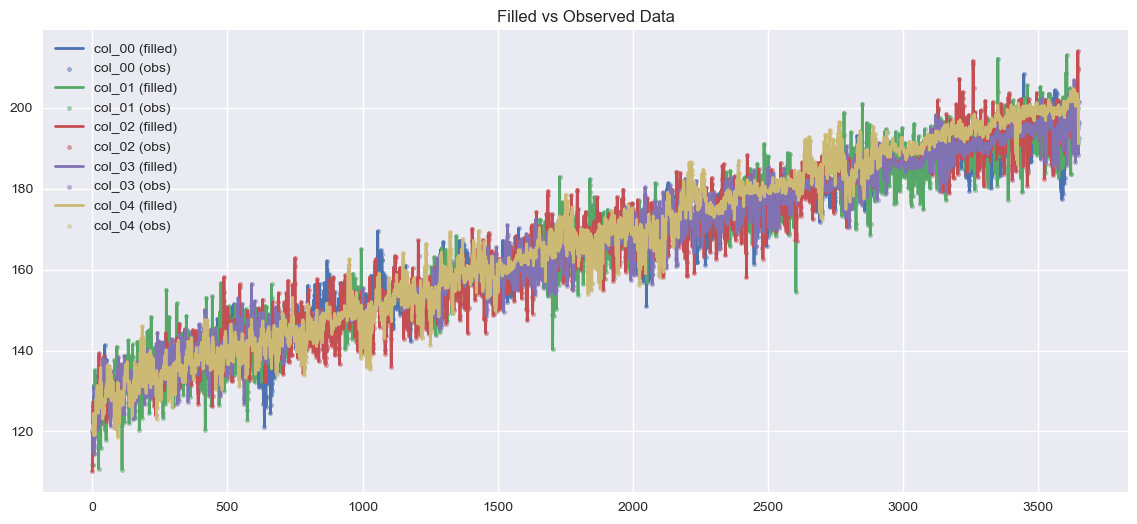

In [10]:
import matplotlib.pyplot as plt

def plot_fill_comparison(X_raw, X_filled, cols, n_cols=5):
    plt.figure(figsize=(14,6))
    
    for i, col in enumerate(cols[:n_cols]):
        plt.plot(X_filled[:, i], label=f"{col} (filled)", linewidth=2)
        
        # plot only observed points
        mask = ~np.isnan(X_raw[:, i])
        plt.scatter(np.where(mask)[0], X_raw[mask, i], s=10, alpha=0.5, label=f"{col} (obs)")
    
    plt.title("Filled vs Observed Data")
    plt.legend()
    plt.show()

plot_fill_comparison(X_raw, X_pca, cols)

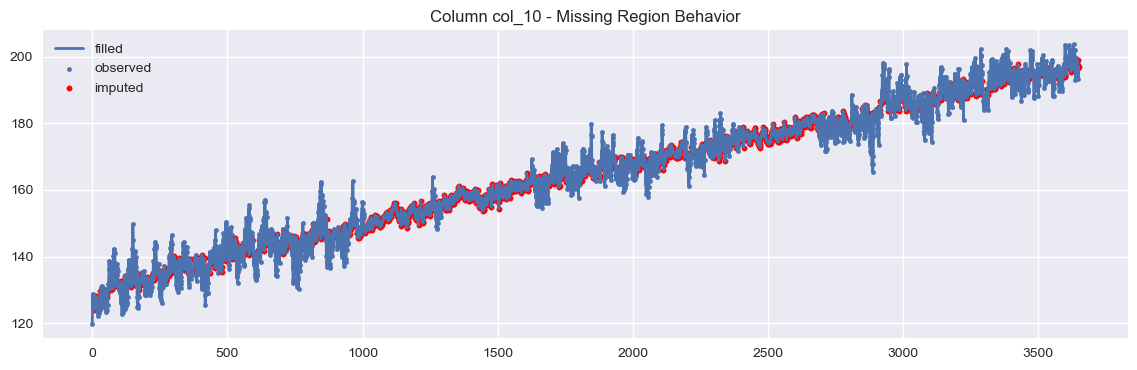

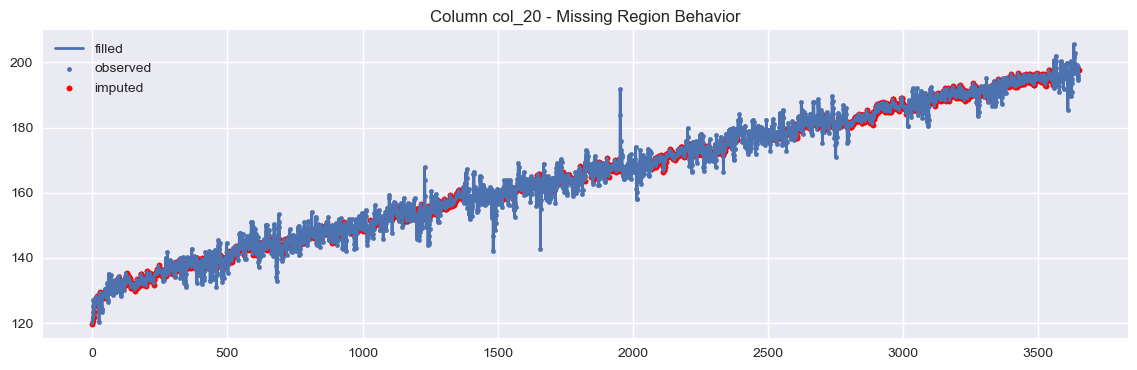

In [11]:
def plot_missing_regions(X_raw, X_filled, col_idx):
    y_raw = X_raw[:, col_idx]
    y_filled = X_filled[:, col_idx]

    missing = np.isnan(y_raw)

    plt.figure(figsize=(14,4))
    plt.plot(y_filled, label="filled", linewidth=2)
    plt.scatter(np.where(~missing)[0], y_raw[~missing], s=10, label="observed")
    plt.scatter(np.where(missing)[0], y_filled[missing], color="red", s=15, label="imputed")
    
    plt.title(f"Column {cols[col_idx]} - Missing Region Behavior")
    plt.legend()
    plt.show()

# try a few
plot_missing_regions(X_raw, X_pca, 10)
plot_missing_regions(X_raw, X_pca, 20)

In [12]:
# =========================================
# 🧠 1. SETUP
# =========================================
import numpy as np
import pandas as pd
from scipy.optimize import nnls
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

cols = [c for c in df.columns if c != "time"]
X = X_pca.copy()

# =========================================
# 🧠 2. HELPER FUNCTION
# =========================================
def adjusted_r2(y, pred, p):
    ss_res = np.sum((y - pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    if ss_tot == 0:
        return 0
    r2 = 1 - ss_res / ss_tot
    n = len(y)
    if n <= p + 1:
        return r2
    return 1 - (1 - r2)*(n-1)/(n-p-1)

# =========================================
# 🚀 3. NNLS TRAIN/TEST STABILITY
# =========================================
n = X.shape[0]
split = n // 2

results = []

for j, col in enumerate(cols):
    Xa = np.delete(X[:split], j, axis=1)
    Xb = np.delete(X[split:], j, axis=1)

    ya = X[:split, j]
    yb = X[split:, j]

    wa, _ = nnls(Xa, ya)
    wb, _ = nnls(Xb, yb)

    pred_ab = Xb @ wa
    pred_ba = Xa @ wb

    r2_ab = adjusted_r2(yb, pred_ab, max(np.sum(wa > 1e-8), 1))
    r2_ba = adjusted_r2(ya, pred_ba, max(np.sum(wb > 1e-8), 1))

    sim = 1 - cosine(wa + 1e-12, wb + 1e-12)
    sim = np.nan_to_num(sim)

    score = 0.5*(r2_ab + r2_ba) + 0.5*sim

    results.append({
        "column": col,
        "score": score,
        "forward_r2": r2_ab,
        "backward_r2": r2_ba,
        "coef_similarity": sim
    })

res = pd.DataFrame(results).sort_values("score", ascending=False).reset_index(drop=True)

display(res.head(15))

,column,score,forward_r2,backward_r2,coef_similarity
0,col_11,1.465612,0.969151,0.978203,0.983870
1,col_50,1.454041,0.962005,0.974662,0.971416
2,col_42,1.437492,0.972799,0.974850,0.927334
3,col_28,1.410459,0.921218,0.908680,0.991021
4,col_05,1.396360,0.909361,0.912089,0.971270
5,col_48,1.395593,0.961198,0.972101,0.857887
6,col_26,1.389913,0.953048,0.954643,0.872135
7,col_30,1.379028,0.972316,0.982413,0.803327
8,col_19,1.329632,0.863090,0.890983,0.905191
9,col_20,1.292019,0.943749,0.939855,0.700433


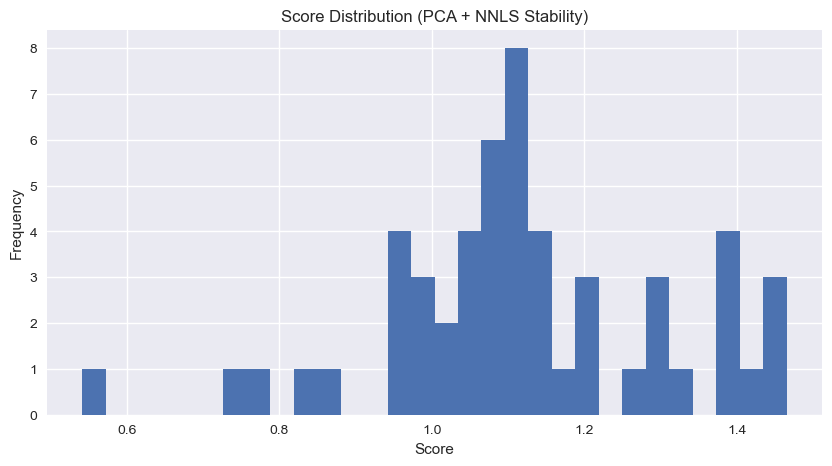

In [13]:
plt.figure(figsize=(10,5))
plt.hist(res["score"], bins=30)
plt.title("Score Distribution (PCA + NNLS Stability)")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

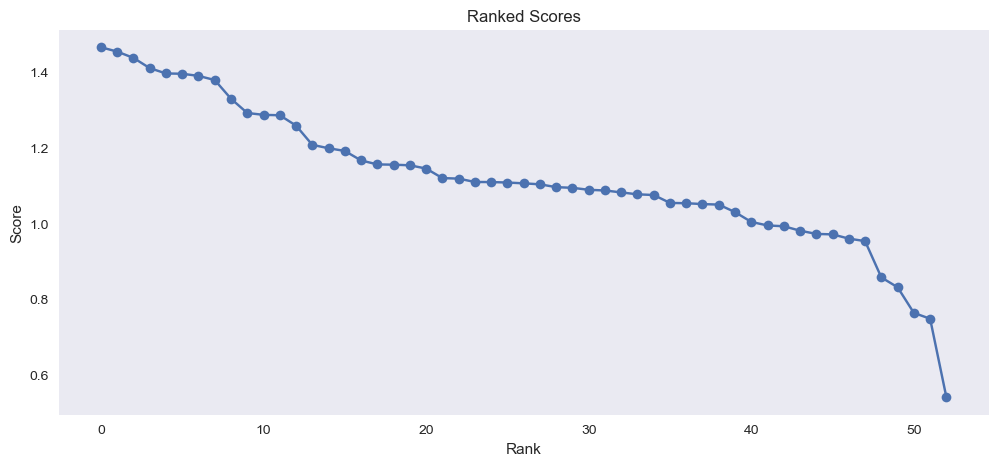

In [14]:
plt.figure(figsize=(12,5))
plt.plot(res["score"].values, marker="o")
plt.title("Ranked Scores")
plt.xlabel("Rank")
plt.ylabel("Score")
plt.grid()
plt.show()

In [15]:
top_candidates = res.head(12)["column"].tolist()
print("Top candidates:", top_candidates)

Top candidates: ['col_11', 'col_50', 'col_42', 'col_28', 'col_05', 'col_48', 'col_26', 'col_30', 'col_19', 'col_20', 'col_40', 'col_46']


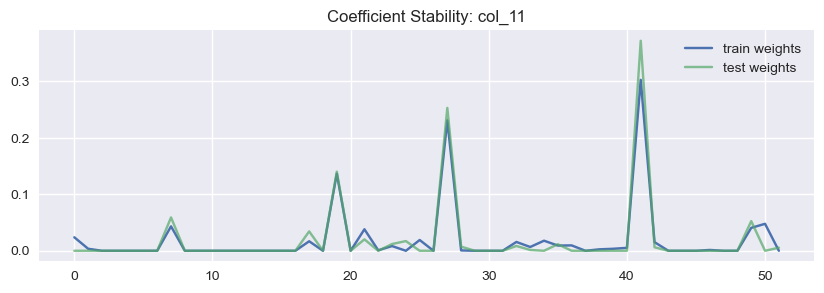

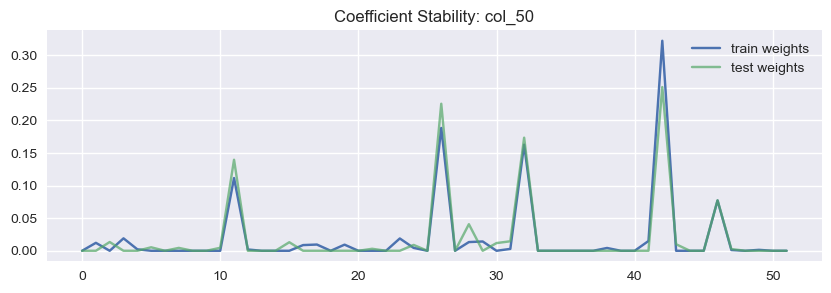

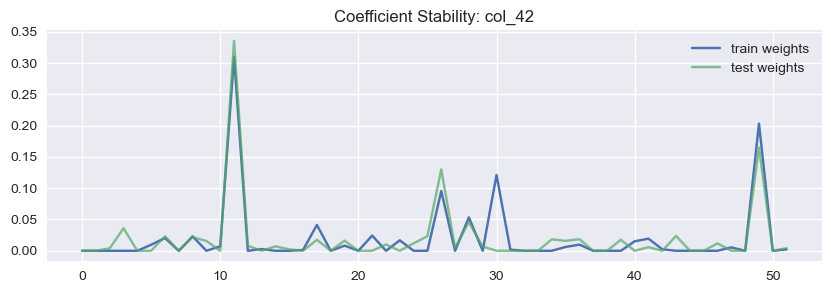

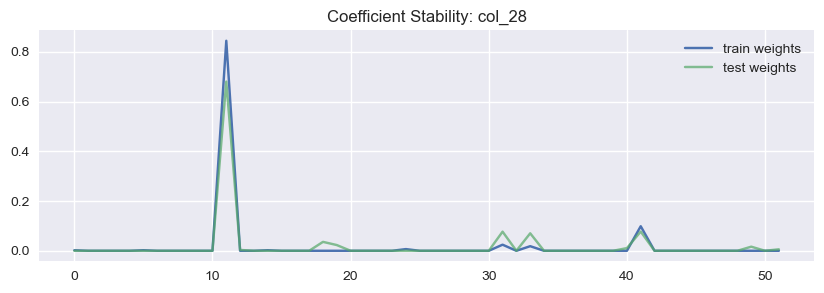

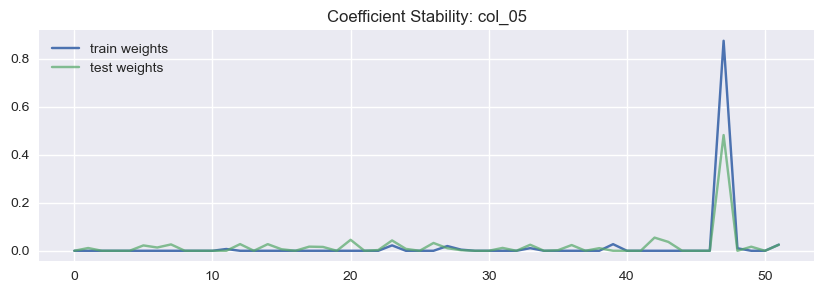

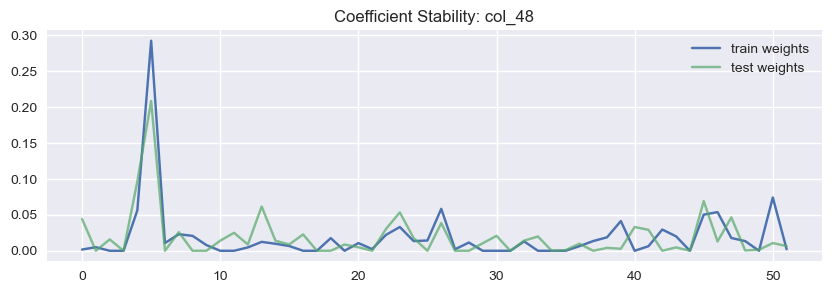

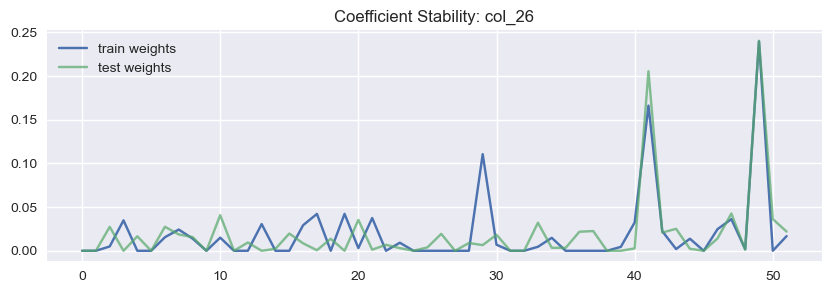

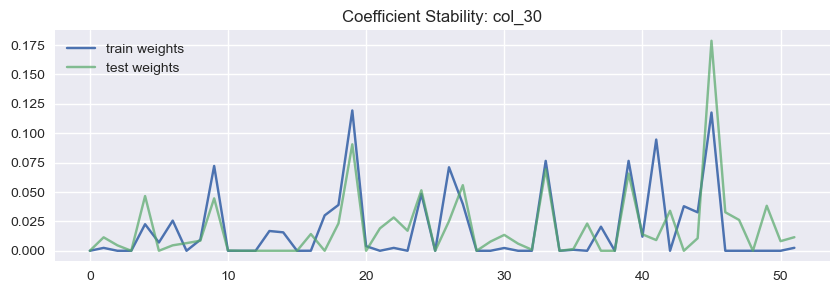

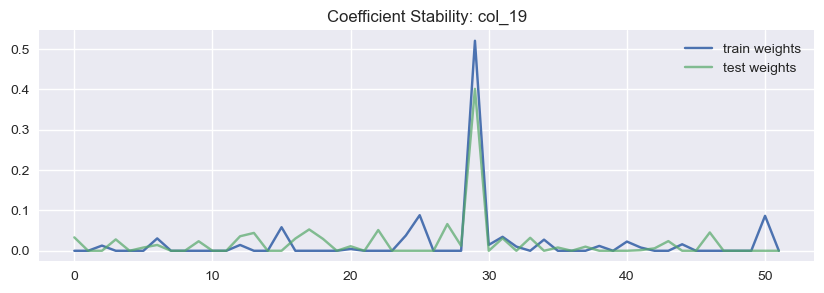

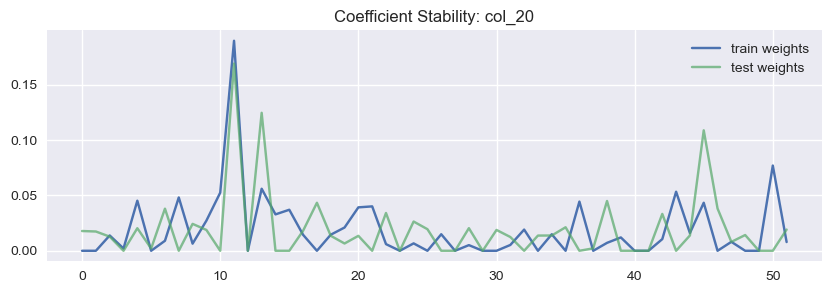

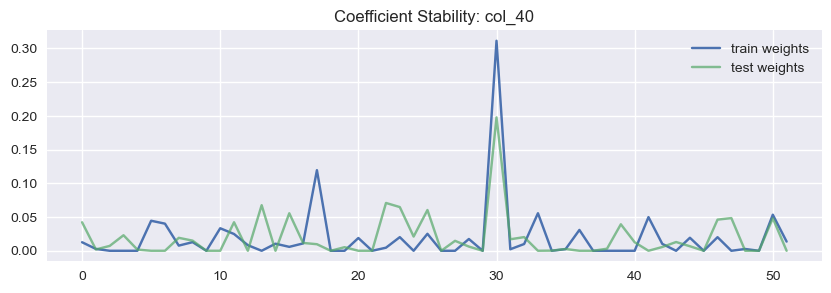

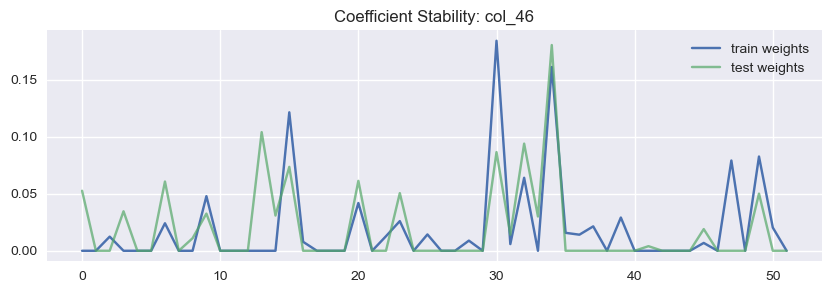

In [17]:
for col in top_candidates[:12]:
    j = cols.index(col)

    Xa = np.delete(X[:split], j, axis=1)
    Xb = np.delete(X[split:], j, axis=1)

    ya = X[:split, j]
    yb = X[split:, j]

    wa, _ = nnls(Xa, ya)
    wb, _ = nnls(Xb, yb)

    plt.figure(figsize=(10,3))
    plt.plot(wa, label="train weights")
    plt.plot(wb, label="test weights", alpha=0.7)
    plt.title(f"Coefficient Stability: {col}")
    plt.legend()
    plt.show()

In [18]:
scores_sorted = res["score"].values

deltas = scores_sorted[:-1] - scores_sorted[1:]

# look only at first 15 for safety
elbow = np.argmax(deltas[:15]) + 1

final_cols = res.head(max(3, elbow))["column"].tolist()

print("Final predicted index columns:")
print(final_cols)

Final predicted index columns:
['col_11', 'col_50', 'col_42', 'col_28', 'col_05', 'col_48', 'col_26', 'col_30', 'col_19', 'col_20', 'col_40', 'col_46', 'col_09']


In [19]:
index_cols = [
    "col_11", "col_50", "col_42",
    "col_28", "col_05", "col_48",
    "col_26", "col_30"
]

farmer_cols = [c for c in cols if c not in index_cols]

In [20]:
# =========================================
# 🧠 1. BOOTSTRAP NNLS FOR COEFFICIENTS
# =========================================
import numpy as np
import pandas as pd
from scipy.optimize import nnls

X = X_pca.copy()

n = X.shape[0]
n_boot = 30  # number of bootstrap samples

coef_results = {}

for idx_col in index_cols:
    j = cols.index(idx_col)
    
    A_full = X[:, [cols.index(c) for c in farmer_cols]]
    y_full = X[:, j]
    
    coefs = []
    
    for _ in range(n_boot):
        # bootstrap sample
        idx = np.random.choice(n, size=int(0.7*n), replace=False)
        
        A = A_full[idx]
        y = y_full[idx]
        
        beta, _ = nnls(A, y)
        coefs.append(beta)
    
    coefs = np.array(coefs)
    
    coef_results[idx_col] = {
        "mean": coefs.mean(axis=0),
        "std": coefs.std(axis=0),
        "nonzero_freq": (coefs > 1e-6).mean(axis=0)
    }

In [21]:
# =========================================
# 📊 TABLE: index -> (farmer, coef, error)
# =========================================
rows = []

for idx_col in index_cols:
    stats = coef_results[idx_col]
    
    for i, farmer in enumerate(farmer_cols):
        mean = stats["mean"][i]
        std = stats["std"][i]
        freq = stats["nonzero_freq"][i]
        
        if mean > 1e-4:  # keep meaningful ones
            rows.append({
                "index": idx_col,
                "farmer": farmer,
                "coef_mean": mean,
                "coef_std": std,
                "nonzero_freq": freq
            })

coef_df = pd.DataFrame(rows)

# sort nicely
coef_df = coef_df.sort_values(["index", "coef_mean"], ascending=[True, False])

display(coef_df.head(30))

,index,farmer,coef_mean,coef_std,nonzero_freq
181,col_05,col_46,0.077130,0.016118,1.000000
184,col_05,col_51,0.071890,0.016391,1.000000
162,col_05,col_21,0.063341,0.012547,1.000000
178,col_05,col_43,0.060573,0.014966,1.000000
157,col_05,col_16,0.059293,0.012808,1.000000
164,col_05,col_24,0.053687,0.002669,1.000000
176,col_05,col_40,0.046237,0.014789,1.000000
175,col_05,col_39,0.045954,0.009462,1.000000
159,col_05,col_18,0.042034,0.010398,1.000000
165,col_05,col_25,0.037935,0.009763,1.000000


In [28]:
# =========================================
# 🔍 SUM OF COEFFICIENTS
# =========================================
for idx_col in index_cols:
    total = coef_results[idx_col]["mean"].sum()
    print(f"{idx_col}: sum(beta) = {total:.3f}")

col_11: sum(beta) = 1.001
col_50: sum(beta) = 1.000
col_42: sum(beta) = 1.001
col_28: sum(beta) = 1.001
col_05: sum(beta) = 1.003
col_48: sum(beta) = 0.998
col_26: sum(beta) = 1.000
col_30: sum(beta) = 1.001


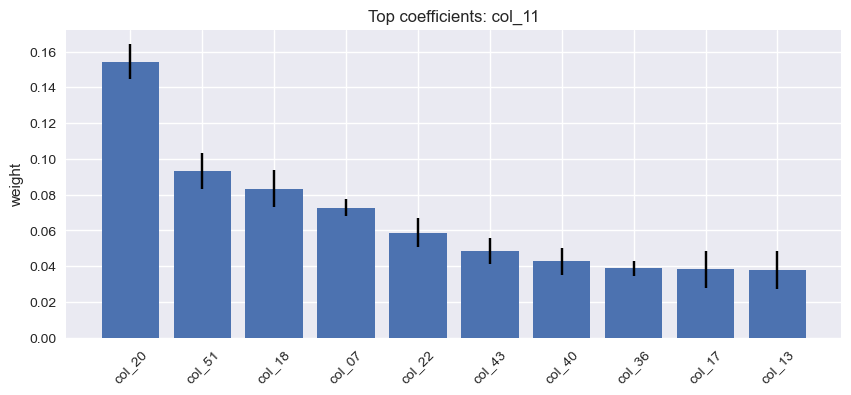

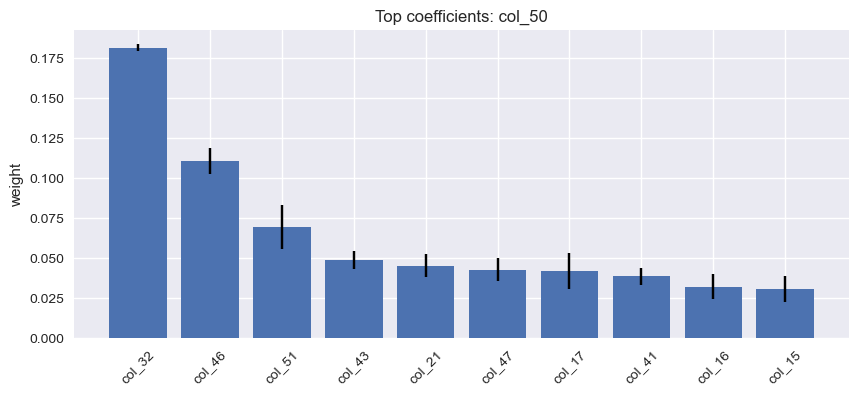

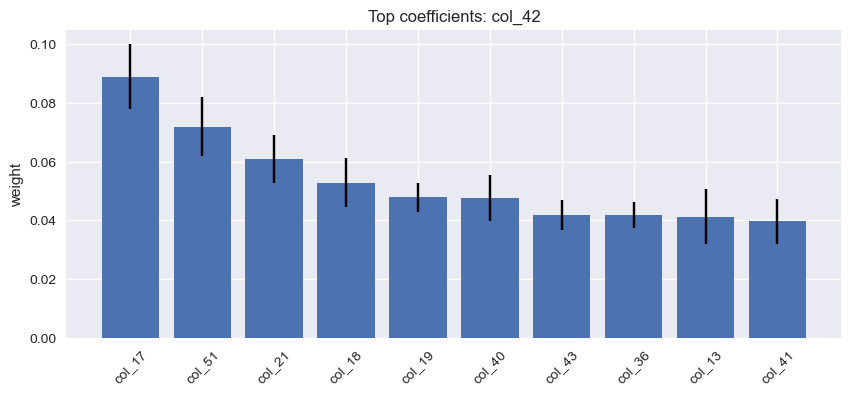

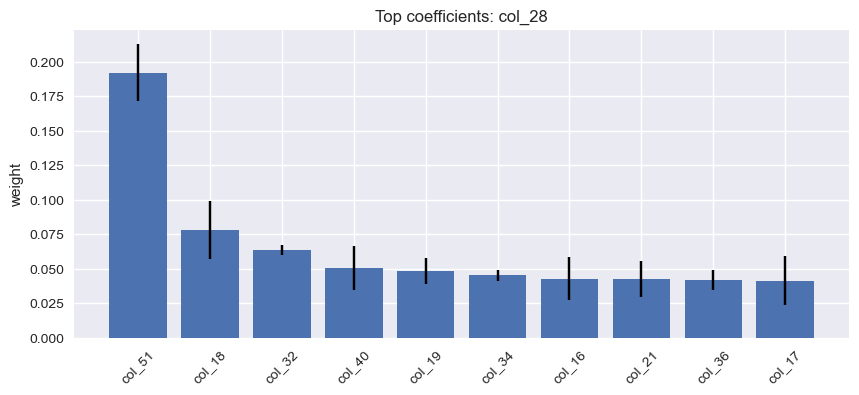

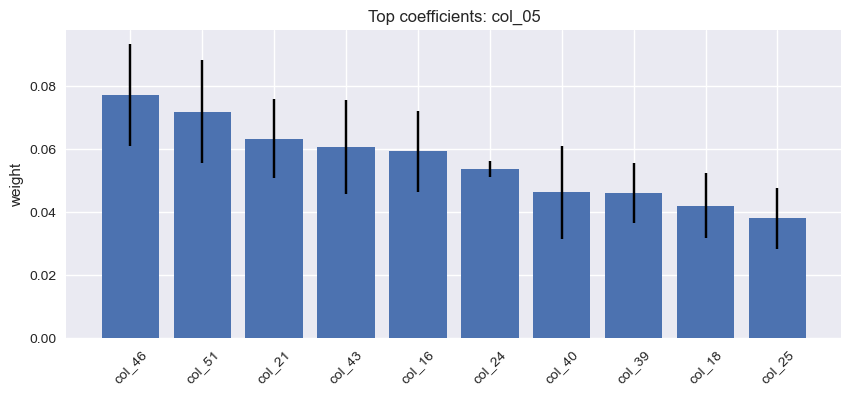

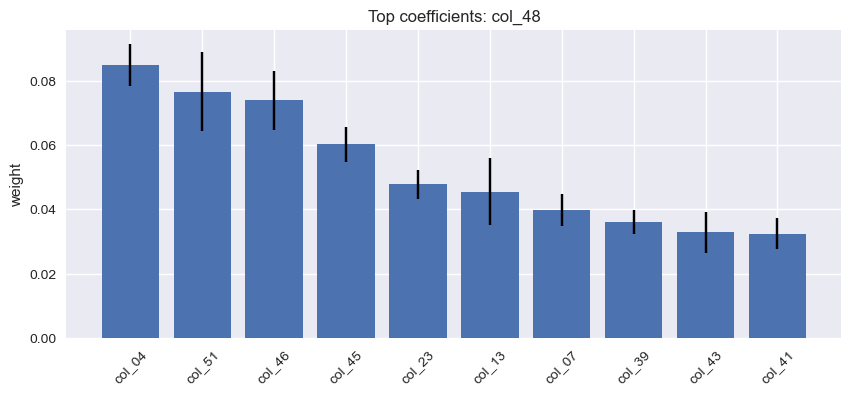

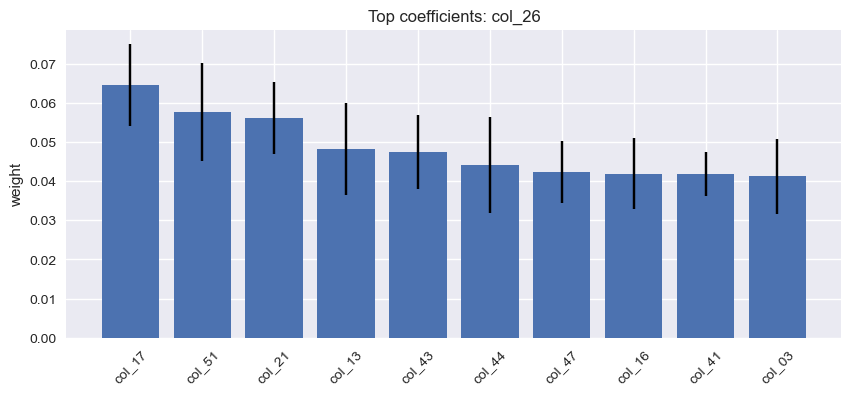

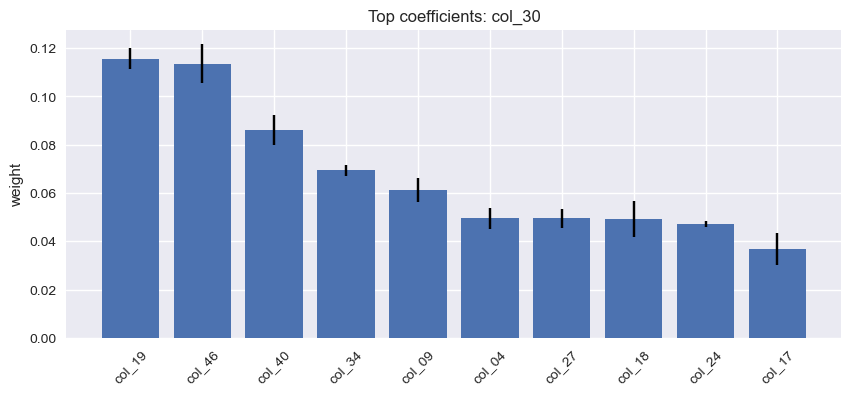

In [29]:
# =========================================
# 📈 PLOT COEFFICIENTS WITH ERROR BARS
# =========================================
import matplotlib.pyplot as plt

for idx_col in index_cols:
    stats = coef_results[idx_col]
    
    mean = stats["mean"]
    std = stats["std"]
    
    # take top 10 contributors
    idx_sorted = np.argsort(mean)[::-1][:10]
    
    plt.figure(figsize=(10,4))
    plt.bar(range(len(idx_sorted)), mean[idx_sorted], yerr=std[idx_sorted])
    
    labels = [farmer_cols[i] for i in idx_sorted]
    plt.xticks(range(len(idx_sorted)), labels, rotation=45)
    
    plt.title(f"Top coefficients: {idx_col}")
    plt.ylabel("weight")
    plt.show()